In [103]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.models import resnet50
import pandas as pd
import scripts.train as train
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from PIL.Image import Image
from torchvision.transforms import ToPILImage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [115]:
model, losses, metrics = train.run_training()

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1: Training accuracy: 0.8984156570363467  Validation accuracy: 0.9015918958031838


  0%|          | 0/101 [00:00<?, ?it/s]

...

  0%|          | 0/22 [00:00<?, ?it/s]

Epoch 8: Training accuracy: 0.9664492078285182  Validation accuracy: 0.934876989869754


  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

Epoch 9: Training accuracy: 0.9847778813296054  Validation accuracy: 0.8610709117221418
Early stopping triggered at epoch 9


In [116]:
losses = pd.DataFrame(losses)
metrics = pd.DataFrame(metrics)

In [117]:
losses

,train,val
0,0.256799,0.225482
1,0.157828,1.372518
2,0.119539,0.179262
3,0.082915,0.385001
4,0.081601,0.344510
5,0.059736,0.112669
6,0.085027,0.635980
7,0.086326,0.201947
8,0.046563,0.666398


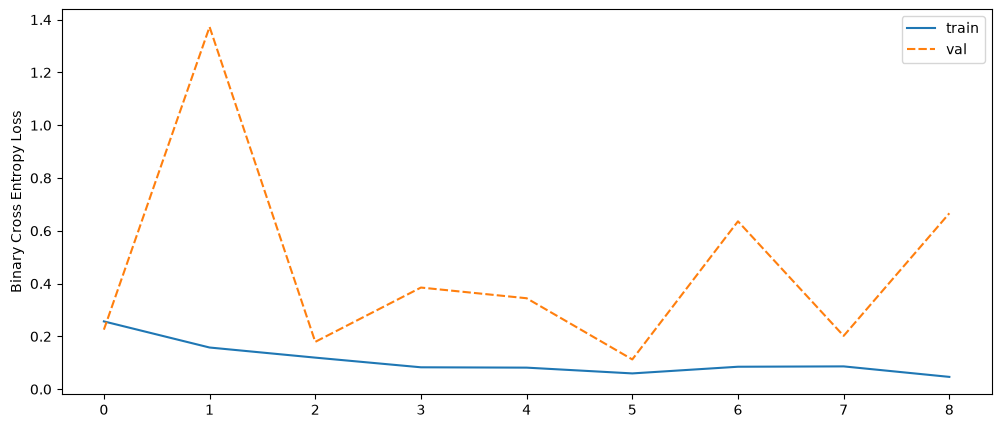

In [118]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=losses)
plt.ylabel('Binary Cross Entropy Loss')
plt.show()

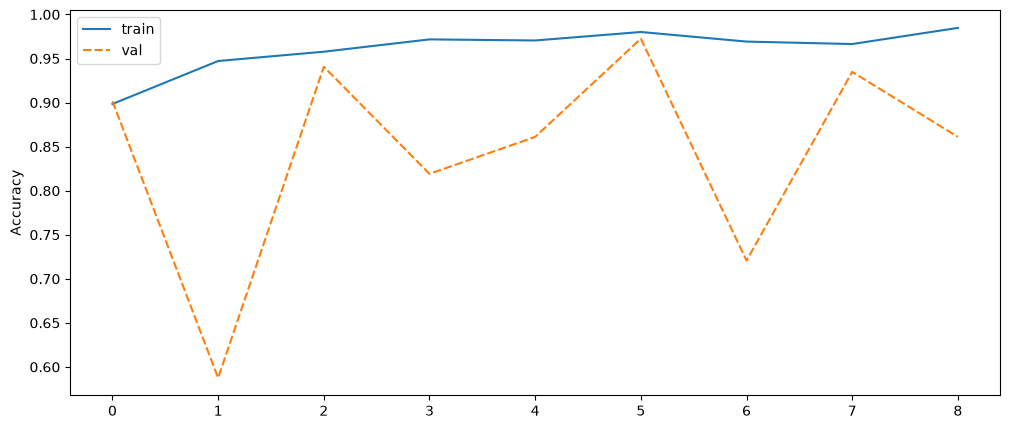

In [119]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=metrics)
plt.ylabel('Accuracy')
plt.show()

In [132]:
_, test_transform = train.set_transforms()
test_dataset = train.make_dataset(set='test', transforms=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [122]:
labels = []
predictions = []

In [123]:
model.eval()
for batch_X, batch_y in test_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    with torch.no_grad():
        outputs = model.forward(batch_X)
        preds = torch.sigmoid(outputs)
    labels.append(batch_y.cpu())
    predictions.append(preds.cpu())

In [124]:
predictions = torch.vstack(predictions).numpy()
labels = torch.hstack(labels).numpy()

In [125]:
precision, recall, thresholds = precision_recall_curve(labels, predictions)

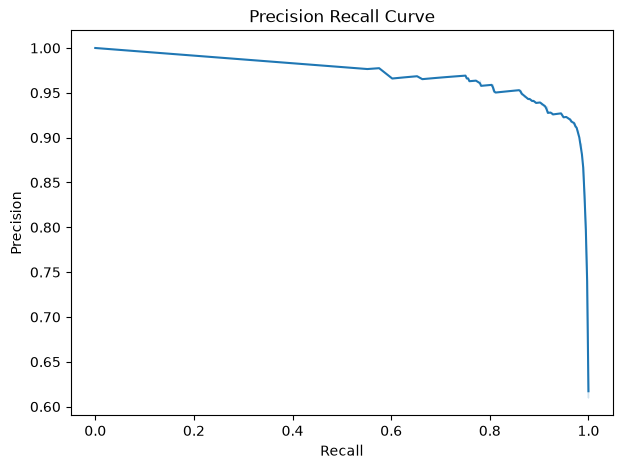

In [131]:
plt.figure(figsize=(7, 5))
sns.lineplot(x=recall, y=precision)
plt.title('Precision Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()